# 二阶龙格-库塔法（RK2）求解匀速圆周运动

- [周详](xiangzhou@whu.edu.cn)
- 武汉大学
- 2026年9月22日

例 1 用前向欧拉法求解匀速圆周运动（各向同性谐振子力 $\boldsymbol{F} = -kr\,\boldsymbol{e}_r$ 维持的半径 $R$、角频率 $\omega_0 = \sqrt{k/m}$ 的圆周运动）：**直角坐标**下数值解螺旋外扩到 3 倍半径开外。本例仍在直角坐标下把方法换成 RK2——二维运动会服从例 4 刚导出的解析律吗？

**直角坐标**：运动方程是两个相互垂直的独立振子

$$
\dot x = v_x, \quad \dot v_x = -\omega_0^2 x; \qquad
\dot y = v_y, \quad \dot v_y = -\omega_0^2 y
$$

解析解 $x = R\cos\omega_0 t$、$y = R\sin\omega_0 t$。RK2（中点形式）：先走半步估出中点速度与位置，再用中点值走整步：

$$
v_{x,n+\frac{1}{2}} = v_{x,n} - \tfrac{h}{2}\,\omega_0^2 x_n, \qquad
x_{n+\frac{1}{2}} = x_n + \tfrac{h}{2}\,v_{x,n}
$$

$$
x_{n+1} = x_n + h\,v_{x,n+\frac{1}{2}}, \qquad
v_{x,n+1} = v_{x,n} - h\,\omega_0^2 x_{n+\frac{1}{2}}
$$

（$y$、$v_y$ 同理。）

**总机械能**：$E = \tfrac{1}{2}m(v_x^2 + v_y^2) + \tfrac{1}{2}k(x^2+y^2)$，精确解中恒为 $E_0 = m\omega_0^2 R^2$（动能与势能各半）。**角动量** $L = m(x v_y - y v_x)$ 精确解中同样守恒。

**运行之前，先把你的预测写下来**：

1. 直角坐标下，例 1 的欧拉解螺旋外扩到半径 3.3。换成 RK2：轨迹还是螺旋吗？会大多少？
2. 例 4 对**一维**振子推出了精确漂移律 $E_n = E_0(1+z^4/4)^n$。这里的二维圆周运动能直接搬用吗？
3. 角动量 $L = m(x v_y - y v_x)$ 在精确解中严格守恒——数值解还能守住吗？

带着预测运行下面的代码，逐条对照。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

# 字体配置：按操作系统自动选择中文字体，
# 西文与数学公式用 Times New Roman 风格（STIX）
import platform
system = platform.system()
if system == 'Darwin':
    cn_font = 'Songti SC'
elif system == 'Windows':
    cn_font = 'SimSun'
else:  # Linux
    cn_font = 'Noto Serif CJK SC'

plt.rcParams['font.family'] = [cn_font, 'Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
def forward_euler_cart(h, n_steps):
    """直角坐标前向欧拉：状态 (x, y, vx, vy)，右端全部用旧值"""
    x  = np.zeros(n_steps + 1); y  = np.zeros(n_steps + 1)
    vx = np.zeros(n_steps + 1); vy = np.zeros(n_steps + 1)
    x[0], y[0], vx[0], vy[0] = R, 0.0, 0.0, omega0 * R
    for n in range(n_steps):
        x[n+1]   = x[n]  + h * vx[n]
        y[n+1]   = y[n]  + h * vy[n]
        vx[n+1]  = vx[n] - h * omega0**2 * x[n]
        vy[n+1]  = vy[n] - h * omega0**2 * y[n]
    return x, y, vx, vy


def rk2_midpoint_cart(h, n_steps):
    """直角坐标 RK2 中点法：半步预估中点状态，再用中点斜率走整步"""
    x  = np.zeros(n_steps + 1); y  = np.zeros(n_steps + 1)
    vx = np.zeros(n_steps + 1); vy = np.zeros(n_steps + 1)
    x[0], y[0], vx[0], vy[0] = R, 0.0, 0.0, omega0 * R
    for n in range(n_steps):
        vx_mid = vx[n] - 0.5 * h * omega0**2 * x[n]    # 中点速度
        vy_mid = vy[n] - 0.5 * h * omega0**2 * y[n]
        x_mid  = x[n] + 0.5 * h * vx[n]                # 中点位置
        y_mid  = y[n] + 0.5 * h * vy[n]
        x[n+1]  = x[n] + h * vx_mid                    # 用中点斜率走整步
        y[n+1]  = y[n] + h * vy_mid
        vx[n+1] = vx[n] - h * omega0**2 * x_mid
        vy[n+1] = vy[n] - h * omega0**2 * y_mid
    return x, y, vx, vy


# 参数（与例 1 欧拉版完全一致，便于对照）
m, k = 1.0, 1.0     # 质量 (kg)、劲度系数 (N/m)
omega0 = np.sqrt(k / m)
R = 1.0             # 圆轨道半径 (m)
h = 0.05            # 时间步长 (s)
t_end = 48.0        # 总时间 (s)，约 7.6 圈
z = omega0 * h      # 无量纲步长

n_steps = int(t_end / h)
t = np.arange(n_steps + 1) * h

x_c, y_c, vx_c, vy_c = rk2_midpoint_cart(h, n_steps)
x_eu, y_eu, vx_eu, vy_eu = forward_euler_cart(h, n_steps)

# 解析解（圆轨道）
x_exact, y_exact = R * np.cos(omega0 * t), R * np.sin(omega0 * t)
vx_exact, vy_exact = -R * omega0 * np.sin(omega0 * t), R * omega0 * np.cos(omega0 * t)

# 能量与角动量
E_c  = 0.5 * m * (vx_c**2 + vy_c**2) + 0.5 * k * (x_c**2 + y_c**2)
E_eu = 0.5 * m * (vx_eu**2 + vy_eu**2) + 0.5 * k * (x_eu**2 + y_eu**2)
E0 = 0.5 * m * (omega0 * R)**2 + 0.5 * k * R**2
L_c  = m * (x_c * vy_c - y_c * vx_c)
L_eu = m * (x_eu * vy_eu - y_eu * vx_eu)
L0 = m * omega0 * R**2

print(f'参数同例 1：m = k = 1, R = 1, h = {h} s（z = {z}），t = {t_end:.0f} s ≈ {t_end * omega0 / (2 * np.pi):.1f} 圈，共 {n_steps} 步')
print(f'每步能量比理论值（例 4 推导）：欧拉法 1 + z^2 = {1 + z**2:.6f}，RK2 1 + z^4/4 = {1 + z**4 / 4:.8f}')
print()
print('【直角坐标】')
print(f'{"":18}{"RK2":>16}{"前向欧拉":>16}')
print(f'{"末能量放大倍数":18}{E_c[-1] / E0:>16.6f}{E_eu[-1] / E0:>16.4f}')
print(f'{"理论放大倍数":18}{(1 + z**4 / 4)**n_steps:>16.6f}{(1 + z**2)**n_steps:>16.4f}')
print(f'{"末半径 (m)":18}{np.hypot(x_c[-1], y_c[-1]):>16.6f}{np.hypot(x_eu[-1], y_eu[-1]):>16.4f}')
print(f'{"末角动量 / L0":18}{L_c[-1] / L0:>16.6f}{L_eu[-1] / L0:>16.4f}')
phi_rk = np.arctan2(y_c[-1], x_c[-1]) % (2 * np.pi)
phi_eu = np.arctan2(y_eu[-1], x_eu[-1]) % (2 * np.pi)
phi_ex = (omega0 * t[-1]) % (2 * np.pi)
print(f'末相位角 (rad)：RK2 {phi_rk:.4f}，欧拉 {phi_eu:.4f}，精确 {phi_ex:.4f}')

参数同例 1：m = k = 1, R = 1, h = 0.05 s（z = 0.05），t = 48 s ≈ 7.6 圈，共 960 步
每步能量比理论值（例 4 推导）：欧拉法 1 + z^2 = 1.002500，RK2 1 + z^4/4 = 1.00000156

【直角坐标】
                               RK2            前向欧拉
末能量放大倍数                   1.001501         10.9902
理论放大倍数                    1.001501         10.9902
末半径 (m)                   1.000750          3.3151
末角动量 / L0                 1.001501         10.9902
末相位角 (rad)：RK2 4.0377，欧拉 3.9778，精确 4.0177


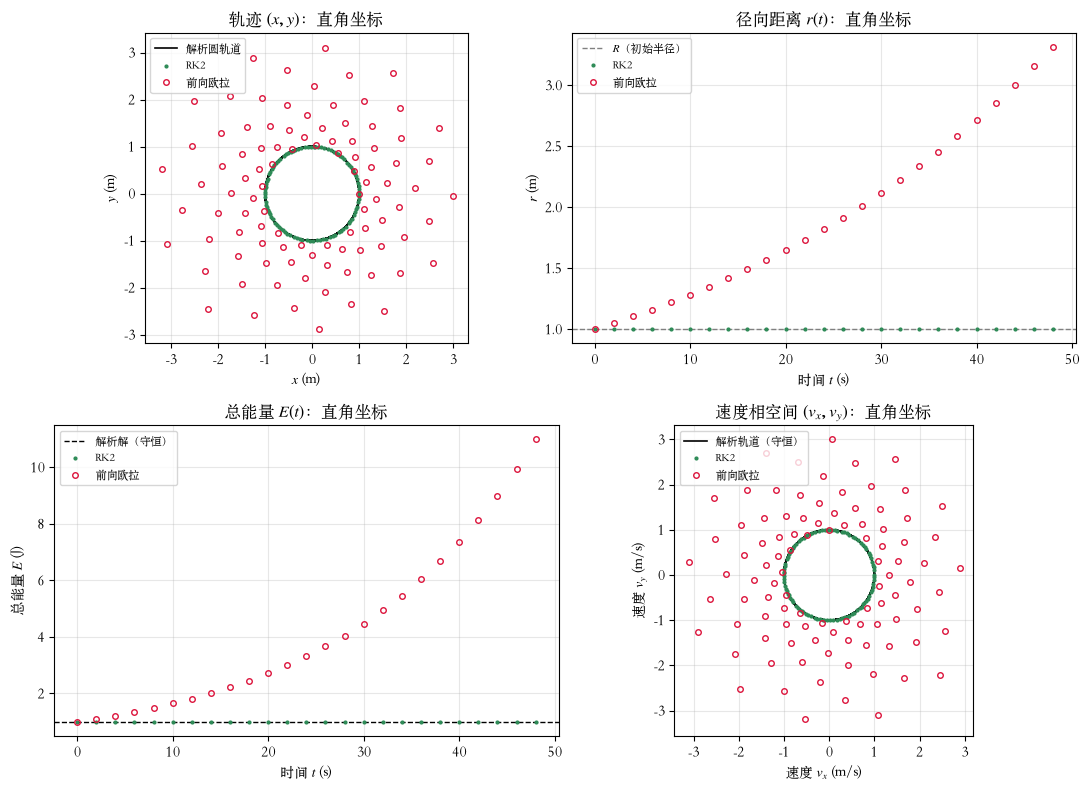

In [3]:
fig, axs = plt.subplots(2, 2, figsize=(11, 8))

# (a) 平面轨迹
ax = axs[0, 0]
th_circle = np.linspace(0, 2 * np.pi, 200)
ax.plot(x_exact, y_exact, 'k-', lw=1.2, label='解析圆轨道')
ax.plot(x_c, y_c, '.', color='seagreen', ms=4, markevery=10, label='RK2')
ax.plot(x_eu, y_eu, 'o', color='crimson', ms=4, mfc='none', markevery=10, label='前向欧拉')
ax.set_xlabel('$x$ (m)')
ax.set_ylabel('$y$ (m)')
ax.set_title('轨迹 $(x, y)$：直角坐标')
ax.set_aspect('equal')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

# (b) 径向距离
ax = axs[0, 1]
ax.axhline(R, color='gray', ls='--', lw=1, label='$R$（初始半径）')
ax.plot(t, np.hypot(x_c, y_c), '.', color='seagreen', ms=4, markevery=40, label='RK2')
ax.plot(t, np.hypot(x_eu, y_eu), 'o', color='crimson', ms=4, mfc='none', markevery=40, label='前向欧拉')
ax.set_xlabel('时间 $t$ (s)')
ax.set_ylabel('$r$ (m)')
ax.set_title('径向距离 $r(t)$：直角坐标')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

# (c) 总能量
ax = axs[1, 0]
ax.axhline(E0, color='k', ls='--', lw=1, label='解析解（守恒）')
ax.plot(t, E_c, '.', color='seagreen', ms=4, markevery=40, label='RK2')
ax.plot(t, E_eu, 'o', color='crimson', ms=4, mfc='none', markevery=40, label='前向欧拉')
ax.set_xlabel('时间 $t$ (s)')
ax.set_ylabel('总能量 $E$ (J)')
ax.set_title('总能量 $E(t)$：直角坐标')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

# (d) 速度相空间
ax = axs[1, 1]
ax.plot(vx_exact, vy_exact, 'k-', lw=1.2, label='解析轨道（守恒）')
ax.plot(vx_c, vy_c, '.', color='seagreen', ms=4, markevery=10, label='RK2')
ax.plot(vx_eu, vy_eu, 'o', color='crimson', ms=4, mfc='none', markevery=10, label='前向欧拉')
ax.set_xlabel('速度 $v_x$ (m/s)')
ax.set_ylabel('速度 $v_y$ (m/s)')
ax.set_title('速度相空间 $(v_x, v_y)$：直角坐标')
ax.set_aspect('equal')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig('outputs/6_circular_motion_rk2_cart.pdf', bbox_inches='tight')
plt.show()

**对照预测**：

1. **还是圆，而且几乎无痕**：RK2 轨迹贴着解析圆——末半径 1.00075；欧拉已螺旋到 3.32、能量放大 11 倍，RK2 的能量只多了 0.15%。
2. **公式原封不动搬来了**：末放大 1.001501 对理论 $(1+z^4/4)^{960}$ = 1.001501，逐位一致；欧拉 10.9902 对 $(1+z^2)^{960}$ 同样精确。$x$、$y$ 各是一个一维振子（例 4），"各向同性"把两个分量绑成同一个比例——角动量 $L$ 也服从同一条律（见打印）。
3. **钟快慢**：末相位 RK2 4.0377 rad（精确 4.0177，提前 0.020 rad $= \omega_0 z^2 t/6$，偏快）；欧拉 3.9778（落后 0.040 rad $= \omega_0 z^2 t/3$，偏慢）——例 4"同阶反号、恰为一半"的结论原样重演。欧拉面板里最抢眼的误差其实来自半径膨胀，相位差反被淹没。

## 为什么漂移可以精确预言？——解耦与各向同性

**例 4 的推导原封不动地升级到二维。** $x$、$y$ 两方向**解耦**，各是一个一维振子——同一个更新矩阵 $M$、同一对特征值 $\lambda = 1 - z^2/2 \pm \mathrm{i}z$。每步：振幅各乘 $|\lambda|$、相位各进 $\arg\lambda$。"各向同性"意味着两个方向**同放大、同转角**，于是：

- 轨迹保持**圆形**（两方向半径同步增长），半径按 $|\lambda|^n$ 缓慢膨胀；
- 总能量是两分量之和，每步同乘 $|\lambda|^2$：$E_n = E_0(1+z^4/4)^n$（欧拉 $(1+z^2)^n$）——打印值逐位吻合；
- 角速度 $= \arg\lambda/h = \omega_0(1 + z^2/6)$，**偏快**；欧拉 $\arctan z/h$ **偏慢**——例 4"同阶反号、恰为一半"在二维原样重演。

**角动量也服从同一条律。** 用复数记号 $w = x + \mathrm{i}y$、$u = v_x + \mathrm{i}v_y$，RK2 更新为 $w' = aw + hu$、$u' = -hw + au$（$a = 1 - z^2/2$），而 $L = \mathrm{Im}(\overline{w}u)$：

$$
L_{n+1} = \mathrm{Im}(\overline{w'}u') = (a^2 + h^2)\,\mathrm{Im}(\overline{w}u) = \left(1 + \frac{z^4}{4}\right) L_n
$$

与能量同一条律——打印值逐位吻合。

**RK2 系列四例至此收官**：

| 系统 | 力的特点 | RK2 的表现 |
| ---- | ---- | ---- |
| 自由落体（例 3） | 常力 | 精确到机器精度（长时间仅剩舍入级漂移） |
| 简谐振子（例 4） | 一维线性 | 漂移律 $E_n = E_0(1+z^4/4)^n$ 解析导出 |
| 大振幅单摆（例 5） | 非线性 | 误差 $O(h^2)$，能量漂移只能数值测量 |
| 圆周运动（本例） | 二维线性 | 同一漂移律照搬，$E$ 与 $L$ 同律 |

方法的阶数决定漂移**多快**，问题的线性程度决定**能否解析**——本例把这两条演示得干干净净。

## 长时间：公式在大 $n$ 时依然逐位精确

直角坐标下把步长加大到 $h = 0.4$ s（$z = 0.4$，每圈仅约 16 步），跑 $t = 150$ s ≈ 24 圈，让能量放大 10 倍以上（欧拉的理论放大倍数 $(1.16)^{375} \approx 1.5\times10^{24}$）。

**预测**：漂移公式还能预告到几位有效数字？RK2 的轨迹会长成什么样？

h = 0.4 s（z = 0.4，每圈约 16 步），t = 150 s ≈ 23.9 圈，共 375 步
                                   RK2                前向欧拉
末放大倍数（数值）                    10.939199           1.485e+24
末放大倍数（理论）                    10.939199           1.485e+24


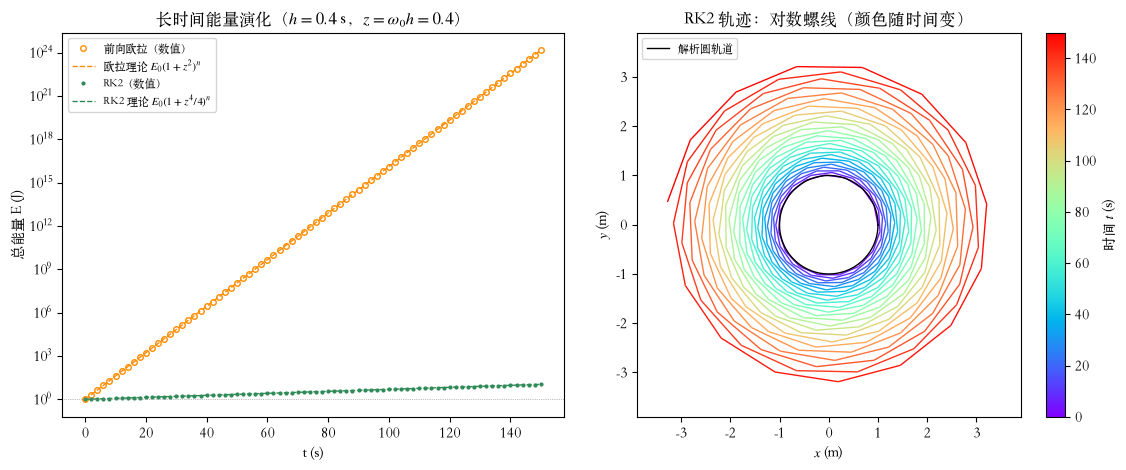

In [4]:
h_long = 0.4                  # 大步长 (s)
t_long = 150.0                # 长时间 (s)
n_long = int(t_long / h_long)
z_long = omega0 * h_long
t_l = np.arange(n_long + 1) * h_long

x_l, y_l, vx_l, vy_l = rk2_midpoint_cart(h_long, n_long)
x_el, y_el, vx_el, vy_el = forward_euler_cart(h_long, n_long)
E_l  = 0.5 * m * (vx_l**2 + vy_l**2) + 0.5 * k * (x_l**2 + y_l**2)
E_el = 0.5 * m * (vx_el**2 + vy_el**2) + 0.5 * k * (x_el**2 + y_el**2)
steps = np.arange(n_long + 1)
E_th_eu = E0 * (1 + z_long**2) ** steps          # 欧拉解析律
E_th_rk = E0 * (1 + z_long**4 / 4) ** steps      # RK2 解析律

print(f'h = {h_long} s（z = {z_long}，每圈约 {2 * np.pi / omega0 / h_long:.0f} 步），t = {t_long:.0f} s ≈ {t_long * omega0 / (2 * np.pi):.1f} 圈，共 {n_long} 步')
print(f'{"":18}{"RK2":>20}{"前向欧拉":>20}')
print(f'{"末放大倍数（数值）":18}{E_l[-1] / E0:>20.6f}{E_el[-1] / E0:>20.3e}')
print(f'{"末放大倍数（理论）":18}{(1 + z_long**4 / 4)**n_long:>20.6f}{(1 + z_long**2)**n_long:>20.3e}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.8))

# (a) semilogy：数值曲线应严丝合缝地压在解析虚线上
ax1.semilogy(t_l, E_el, 'o', color='darkorange', ms=4, mfc='none', markevery=5, label='前向欧拉（数值）')
ax1.semilogy(t_l, E_th_eu, '--', color='darkorange', lw=1, label=r'欧拉理论 $E_0(1+z^2)^n$')
ax1.semilogy(t_l, E_l, '.', color='seagreen', ms=4, markevery=5, label='RK2（数值）')
ax1.semilogy(t_l, E_th_rk, '--', color='seagreen', lw=1, label=r'RK2 理论 $E_0(1+z^4/4)^n$')
ax1.axhline(E0, color='gray', lw=0.5, ls=':')
ax1.set_xlabel('t (s)')
ax1.set_ylabel('总能量 E (J)')
ax1.set_title(f'长时间能量演化（$h = {h_long}$ s，$z = \\omega_0 h = {z_long}$）')
ax1.legend(fontsize=8, loc='upper left')

# (b) RK2 轨迹：膨胀的对数螺线
pts = np.array([x_l, y_l]).T.reshape(-1, 1, 2)
segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
lc = LineCollection(segs, cmap='rainbow', array=t_l, lw=1)
ax2.add_collection(lc)
th_circle = np.linspace(0, 2 * np.pi, 200)
ax2.plot(np.cos(th_circle), np.sin(th_circle), 'k-', lw=1, label='解析圆轨道')
ax2.set_xlabel('$x$ (m)')
ax2.set_ylabel('$y$ (m)')
ax2.set_aspect('equal')
ax2.set_xlim(-3.9, 3.9)
ax2.set_ylim(-3.9, 3.9)
ax2.set_title('RK2 轨迹：对数螺线（颜色随时间变）')
ax2.legend(fontsize=8, loc='upper left')
fig.colorbar(lc, ax=ax2, label='时间 $t$ (s)')

plt.tight_layout()
fig.savefig('outputs/6_circular_motion_rk2_long.pdf', bbox_inches='tight')
plt.show()

**读图**：

1. **左图**：数值曲线在跨越约 24 个数量级的纵轴上严丝合缝地压在各自的解析虚线上（10.939199 对 10.939199）——公式是精确律，不是拟合。
2. **右图**：RK2 轨迹是缓慢外旋的**对数螺线**——每步转过恒定角度 $\arg\lambda$、半径乘恒定比例 $|\lambda|$，与例 4 一维情形完全同一几何。
3. **命运与快慢**：$|\lambda|^2 = 1 + z^4/4 > 1$ 对任何步长成立——RK2 对振子类系统没有稳定步长，只把漂移率从 ∝h 降到 ∝h³（例 4 同一结论）；左图里欧拉的理论放大 $1.5\times10^{24}$ 倍，同为无界、快慢悬殊。

## 结论与思考

- **例 4 的公式照搬**——$x$、$y$ 解耦 + 各向同性 ⇒ 轨迹保持圆形、半径按 $|\lambda|^n$ 膨胀；$E$ 与 $L$ 同用 $E_n = E_0(1+z^4/4)^n$ 逐位预告；角速度偏快 $z^2/6$（欧拉偏慢 $z^2/3$）。
- 与例 1 欧拉对照：同一步长下 RK2 的螺旋慢了约 $h^2$ 倍——方法升级改变快慢，改变不了"漂移"的宿命。
- **无稳定步长**：$|\lambda| > 1$ 对任何 $h$ 成立——RK2 只把漂移率从 ∝h 降到 ∝h³，与欧拉同宿命、快慢悬殊（同图上欧拉理论放大 $1.5\times10^{24}$ 倍）。

**思考**：

1. 各向异性：若 $x$、$y$ 方向劲度不同（$k_x \neq k_y$），轨迹还保持圆形吗？$E$、$L$ 的漂移公式还逐位成立吗？（提示：解耦还在，各向同性没了——两个方向的 $\lambda$ 不再相同。）
2. 椭圆轨道：取 $v_y(0) = 0.5\,\omega_0 R$。直角坐标 RK2 画出的轨迹是什么形状？$E$、$L$ 的漂移公式还逐位成立吗？（提示：解耦与各向同性都不依赖"圆"这个初条件。）
3. 补全本例省略的一步：由 $w' = aw + hu$、$u' = -hw + au$、$L = \mathrm{Im}(\overline{w}u)$ 详细证明 $L_{n+1} = (a^2 + h^2)L_n$，并说明为什么对前向欧拉法同样的计算给出 $(1 + z^2)L_n$。